In [484]:
#the usuals
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import datetime
from datetime import timedelta
from math import sqrt
import importlib
from tqdm import tqdm

# plots
from matplotlib import style
style.use('default')

# Modeling
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.optimizers import Adam
from keras.callbacks import Callback
from keras.models import load_model

# Our custom utility functions
import utils
utils = importlib.reload(utils) #reload if utils.py is modified.
from utils import csvfileread, read_and_rename,create_dataset,convert_timestamp

In [485]:
# Data between 2018 and 2024 
data_path = "Data/"
files = glob.glob(data_path + "load_and_weather_data*")
df = pd.read_csv(files[0])

In [486]:
df

,Unnamed: 0,timestamp,tmpc,relh,sped,feel,p01m,ERCOT
0,0,2018-01-01 01:00:00,-0.833333,91.393333,12.777778,20.792222,0.0,50567.069682
1,1,2018-01-01 02:00:00,-1.284444,90.400000,12.266667,20.203333,0.0,50617.087977
2,2,2018-01-01 03:00:00,-1.752222,91.590000,11.883333,19.276667,0.0,50694.300087
3,3,2018-01-01 04:00:00,-1.895556,90.946667,12.905556,18.685556,0.0,50999.591693
4,4,2018-01-01 05:00:00,-1.968889,89.366667,12.394444,18.707778,0.0,51723.732017
...,...,...,...,...,...,...,...,...
61363,61363,2024-12-31 20:00:00,10.124444,54.446667,3.577778,49.871111,0.0,47619.264355
61364,61364,2024-12-31 21:00:00,9.574444,63.366667,5.494444,47.508889,0.0,46737.678611
61365,61365,2024-12-31 22:00:00,8.994444,64.966667,6.388889,46.236667,0.0,45775.649767
61366,61366,2024-12-31 23:00:00,8.068889,65.713333,4.727778,45.061111,0.0,44779.606498


In [487]:
#filling missing values with linear interpolation
#PLEASE Interpolate only the columns you need -- you don't want timestamps col
#merged_df=merged_df.interpolate(method='linear')
df.columns
for col in df.columns:
    if col!='timestamp':
        #print(f'{col}')
        df[col] = df[col].interpolate(method='linear')

In [488]:
# Sort the DataFrame by index
df['timestamp']=pd.to_datetime(df.timestamp)
# df.set_index('timestamp', inplace=True)
df = df.sort_index()

In [489]:
df=df.drop(columns='Unnamed: 0')

In [490]:
df

,timestamp,tmpc,relh,sped,feel,p01m,ERCOT
0,2018-01-01 01:00:00,-0.833333,91.393333,12.777778,20.792222,0.0,50567.069682
1,2018-01-01 02:00:00,-1.284444,90.400000,12.266667,20.203333,0.0,50617.087977
2,2018-01-01 03:00:00,-1.752222,91.590000,11.883333,19.276667,0.0,50694.300087
3,2018-01-01 04:00:00,-1.895556,90.946667,12.905556,18.685556,0.0,50999.591693
4,2018-01-01 05:00:00,-1.968889,89.366667,12.394444,18.707778,0.0,51723.732017
...,...,...,...,...,...,...,...
61363,2024-12-31 20:00:00,10.124444,54.446667,3.577778,49.871111,0.0,47619.264355
61364,2024-12-31 21:00:00,9.574444,63.366667,5.494444,47.508889,0.0,46737.678611
61365,2024-12-31 22:00:00,8.994444,64.966667,6.388889,46.236667,0.0,45775.649767
61366,2024-12-31 23:00:00,8.068889,65.713333,4.727778,45.061111,0.0,44779.606498


In [491]:
# Assuming 'merged_df' is already loaded and looks like the image
# If you need to load it from a CSV, uncomment and modify the line below:

# Ensure the 'timestamp' column is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Create a DataFrame for 2018 to 2023 data
df_2018_2023 = df[df['timestamp'].dt.year <= 2023].copy()

# Create a DataFrame for 2024 data
df_2024 = df[df['timestamp'].dt.year == 2024].copy()

# Save the DataFrames to CSV files
df_2018_2023.to_csv('data_2018_2023.csv', index=False)
df_2024.to_csv('data_2024.csv', index=False)

print("Data for 2018-2023 saved to 'data_2018_2023.csv'")
print("Data for 2024 saved to 'data_2024.csv'")

Data for 2018-2023 saved to 'data_2018_2023.csv'
Data for 2024 saved to 'data_2024.csv'


In [492]:
df_2018_2023.head()

,timestamp,tmpc,relh,sped,feel,p01m,ERCOT
0,2018-01-01 01:00:00,-0.833333,91.393333,12.777778,20.792222,0.0,50567.069682
1,2018-01-01 02:00:00,-1.284444,90.400000,12.266667,20.203333,0.0,50617.087977
2,2018-01-01 03:00:00,-1.752222,91.590000,11.883333,19.276667,0.0,50694.300087
3,2018-01-01 04:00:00,-1.895556,90.946667,12.905556,18.685556,0.0,50999.591693
4,2018-01-01 05:00:00,-1.968889,89.366667,12.394444,18.707778,0.0,51723.732017


In [493]:
df_2018_2023.set_index('timestamp', inplace=True)

In [494]:
df_2018_2023.head()

,tmpc,relh,sped,feel,p01m,ERCOT
timestamp,,,,,,
2018-01-01 01:00:00,-0.833333,91.393333,12.777778,20.792222,0.0,50567.069682
2018-01-01 02:00:00,-1.284444,90.400000,12.266667,20.203333,0.0,50617.087977
2018-01-01 03:00:00,-1.752222,91.590000,11.883333,19.276667,0.0,50694.300087
2018-01-01 04:00:00,-1.895556,90.946667,12.905556,18.685556,0.0,50999.591693
2018-01-01 05:00:00,-1.968889,89.366667,12.394444,18.707778,0.0,51723.732017


In [495]:
df_2024.head()

,timestamp,tmpc,relh,sped,feel,p01m,ERCOT
52583,2024-01-01 00:00:00,10.815556,100.0,2.938889,49.870000,0.0,41621.968883
52584,2024-01-01 01:00:00,9.833333,100.0,4.663889,47.723333,0.0,41223.480177
52585,2024-01-01 02:00:00,9.338889,100.0,4.216667,46.966667,0.0,41479.399746
52586,2024-01-01 03:00:00,9.024444,100.0,3.833333,46.178889,0.0,41472.770126
52587,2024-01-01 04:00:00,9.018889,100.0,3.322222,46.141111,0.0,41477.440791


In [496]:
df_2024.set_index('timestamp', inplace=True)

In [497]:
df_2024.head()

,tmpc,relh,sped,feel,p01m,ERCOT
timestamp,,,,,,
2024-01-01 00:00:00,10.815556,100.0,2.938889,49.870000,0.0,41621.968883
2024-01-01 01:00:00,9.833333,100.0,4.663889,47.723333,0.0,41223.480177
2024-01-01 02:00:00,9.338889,100.0,4.216667,46.966667,0.0,41479.399746
2024-01-01 03:00:00,9.024444,100.0,3.833333,46.178889,0.0,41472.770126
2024-01-01 04:00:00,9.018889,100.0,3.322222,46.141111,0.0,41477.440791


In [498]:
# Define the features to be scaled
features_to_scale = ['ERCOT',
    'tmpc', 'relh', 'sped', 'feel', 'p01m'
]

In [499]:
# Normalize the features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_2018_2023[features_to_scale])

In [500]:
# Split the data into training and testing sets
train_size = int(len(scaled_data) * 0.8)
train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]

In [501]:
np.shape(train_data)

(42066, 6)

In [502]:
# Prepare data for LSTM model
def create_dataset(dataset, window_size=1):
    data_x, data_y = [], []
    for i in range(len(dataset) - window_size):
        data_x.append(dataset[i:(i + window_size), :])
        data_y.append(dataset[i + window_size, 0])
    return np.array(data_x), np.array(data_y)

In [503]:
# Create datasets for LSTM
window_size = 24
learning_rate = 0.001
train_x, train_y = create_dataset(train_data, window_size)
test_x, test_y = create_dataset(test_data, window_size)

In [504]:
# Reshape input to [samples, time steps, features]
train_x = np.reshape(train_x, (train_x.shape[0], train_x.shape[1], train_x.shape[2]))
test_x = np.reshape(test_x, (test_x.shape[0], test_x.shape[1], test_x.shape[2]))


In [505]:
# # Build the LSTM model
# model = Sequential()
# model.add(LSTM(50, input_shape=(window_size, train_x.shape[2])))
# model.add(Dropout(0.2))
# model.add(Dense(1))
# optimizer = Adam(learning_rate = learning_rate)
# model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])
# #model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [506]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(100, input_shape=(window_size, train_x.shape[2]), return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(50, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(25))
model.add(Dropout(0.3))
model.add(Dense(1))
optimizer = Adam(learning_rate=learning_rate)
model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])

C:\Users\sajib\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [507]:
# Train the model 
history = model.fit(train_x, train_y, epochs=20, batch_size=64, validation_data=(test_x, test_y), verbose=1)


Epoch 1/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 146s 174ms/step - loss: 0.0144 - mae: 0.0859 - val_loss: 0.0034 - val_mae: 0.0469
Epoch 2/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 139s 212ms/step - loss: 0.0036 - mae: 0.0462 - val_loss: 0.0017 - val_mae: 0.0328
Epoch 3/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 146s 219ms/step - loss: 0.0025 - mae: 0.0390 - val_loss: 0.0011 - val_mae: 0.0267
Epoch 4/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 152s 231ms/step - loss: 0.0018 - mae: 0.0329 - val_loss: 5.9727e-04 - val_mae: 0.0190
Epoch 5/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 185s 205ms/step - loss: 0.0013 - mae: 0.0275 - val_loss: 3.7958e-04 - val_mae: 0.0152
Epoch 6/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 133s 190ms/step - loss: 0.0012 - mae: 0.0255 - val_loss: 6.4637e-04 - val_mae: 0.0200
Epoch 7/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 156s 211ms/step - loss: 0.0011 - mae: 0.0244 - val_loss: 3.4265e-04 - val_mae: 0.0141
Epoch 8/20
657/657 ━━━━━━━━━━━━━━━━━━━━ 45s 69ms/step - loss: 9.9180e-04 - mae: 0.0233 - val_loss: 1.9292e-04 - val_mae: 0.0105
Ep

In [508]:
#Save the model
#model.save('my_lstm_model_ERCOT.h5')
model.save('my_lstm_model_2018_2023.keras')

In [509]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                       │ (None, 24, 100)             │          42,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 24, 100)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_14 (LSTM)                       │ (None, 24, 50)              │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 24, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,880 (944.85 KB)

 Trainable params: 80,626 (314.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 161,254 (629.90 KB)

In [510]:
# Make predictions with LSTM model
train_predict = model.predict(train_x)
test_predict = model.predict(test_x)

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 56s 40ms/step
328/328 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step


In [511]:
# Inverse transform predictions to original scale
train_predict = scaler.inverse_transform(np.concatenate((train_predict, np.zeros((train_predict.shape[0], train_x.shape[2] - 1))), axis=1))[:, 0]
train_y = scaler.inverse_transform(np.concatenate((train_y.reshape(-1, 1), np.zeros((train_y.shape[0], train_x.shape[2] - 1))), axis=1))[:, 0]

test_predict = scaler.inverse_transform(np.concatenate((test_predict, np.zeros((test_predict.shape[0], test_x.shape[2] - 1))), axis=1))[:, 0]
test_y = scaler.inverse_transform(np.concatenate((test_y.reshape(-1, 1), np.zeros((test_y.shape[0], test_x.shape[2] - 1))), axis=1))[:, 0]


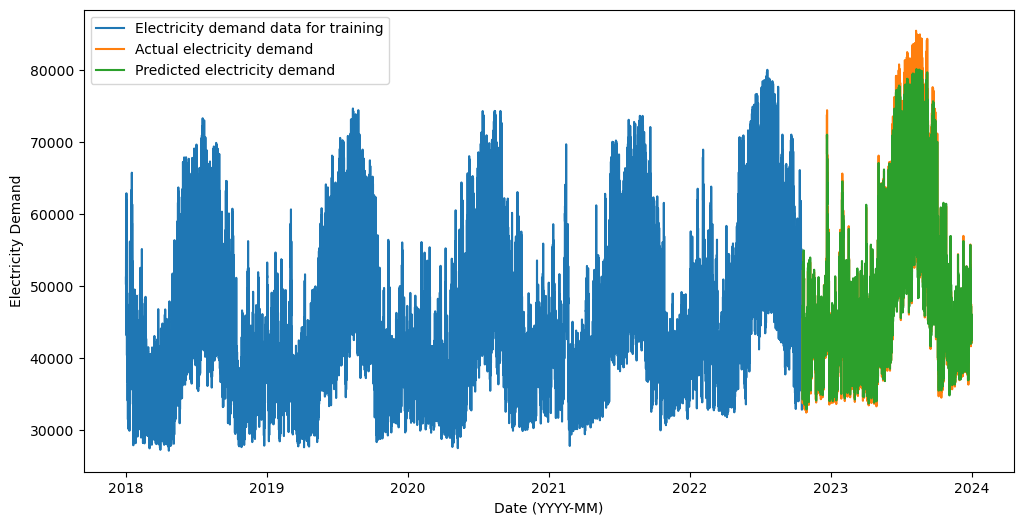

In [512]:
# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(df_2018_2023.index[:len(train_y)], train_y, label="Electricity demand data for training")
plt.plot(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_y, label="Actual electricity demand")
plt.plot(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_predict, label="Predicted electricity demand")
plt.xlabel('Date (YYYY-MM)')
plt.ylabel('Electricity Demand')
plt.legend()
plt.show()

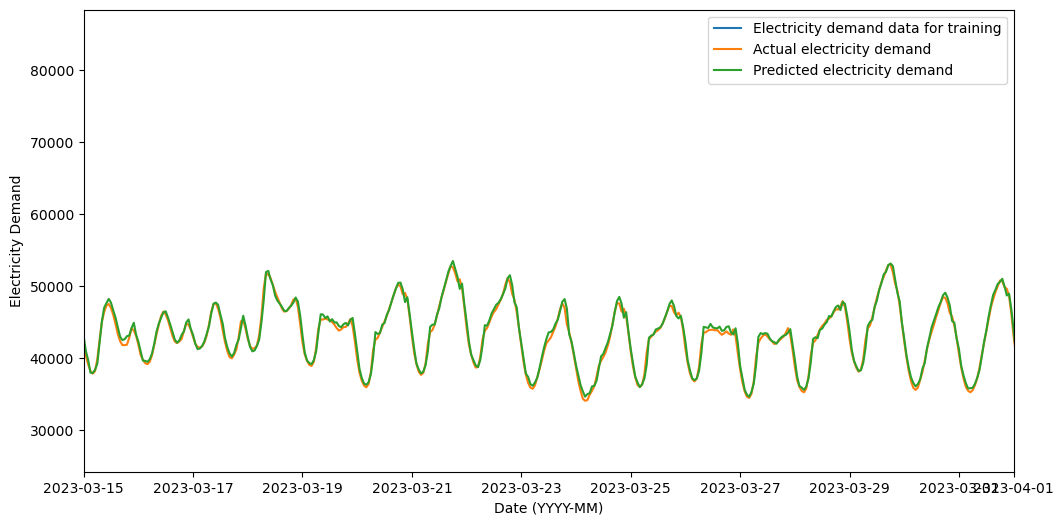

In [513]:
# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(df_2018_2023.index[:len(train_y)], train_y, label="Electricity demand data for training")
plt.plot(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_y, label="Actual electricity demand")
plt.plot(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_predict,'-', label="Predicted electricity demand")
plt.xlabel('Date (YYYY-MM)')
plt.ylabel('Electricity Demand')
plt.legend()
plt.xlim(datetime.datetime(2023, 3, 15), datetime.datetime(2023, 4, 1))
# Save the plot as an image
#plt.savefig('electricity_demand_prediction2.png', dpi=300)
plt.show()

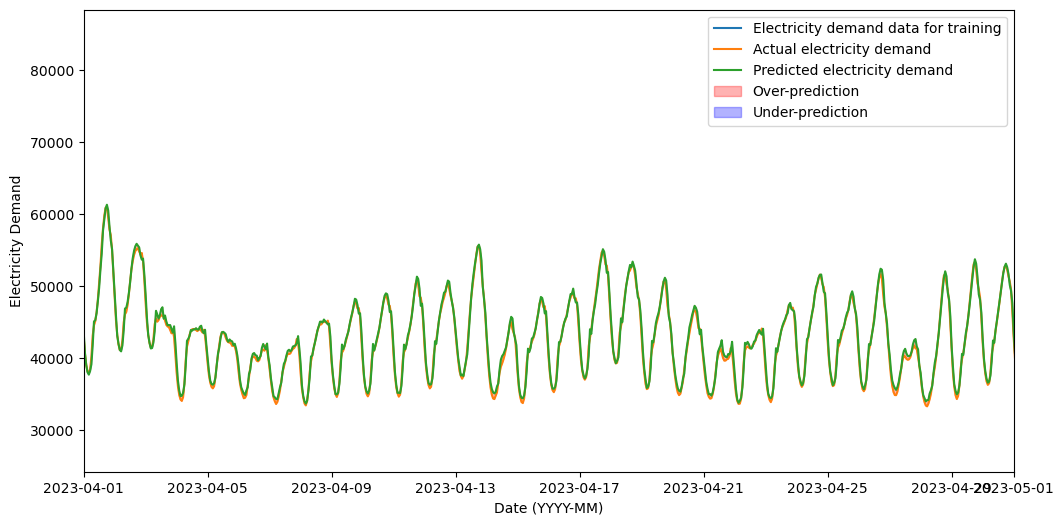

In [514]:
plt.figure(figsize=(12, 6))
plt.plot(df_2018_2023.index[:len(train_y)], train_y, label="Electricity demand data for training")
plt.plot(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_y, label="Actual electricity demand")
plt.plot(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_predict, '-', label="Predicted electricity demand")

# Highlight prediction errors
over_pred = test_predict > test_y
under_pred = test_predict < test_y

plt.fill_between(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_y, test_predict,
                 where=over_pred, interpolate=True, color='red', alpha=0.3, label='Over-prediction')
plt.fill_between(df_2018_2023.index[len(train_y):len(train_y) + len(test_y)], test_y, test_predict,
                 where=under_pred, interpolate=True, color='blue', alpha=0.3, label='Under-prediction')

plt.xlabel('Date (YYYY-MM)')
plt.ylabel('Electricity Demand')
plt.legend()
plt.xlim(datetime.datetime(2023, 4, 1), datetime.datetime(2023, 5, 1))
plt.show()


In [515]:
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt

# Assuming test_y and test_predict are already defined and are numpy arrays or pandas Series
# For demonstration purposes, I've included example dummy data for test_y and test_predict:
# test_y = np.array([10, 12, 15, 11, 13])
# test_predict = np.array([10.5, 11.8, 14.5, 11.2, 12.8])

# Calculate Mean Absolute Error (MAE) Percentage
MAE_percentage = np.nanmean(np.abs(test_y - test_predict) / np.mean(test_y)) * 100

# Calculate Root Mean Square Error (RMSE) in Units
test_rmse = sqrt(mean_squared_error(test_y, test_predict))

# Calculate Root Mean Square Error (RMSE) Percentage
RMSE_percentage = (test_rmse / np.mean(test_y)) * 100

# Print the results
print(f"Mean Absolute Error (MAE) Percentage: {MAE_percentage:.2f}%")
print(f"Root Mean Square Error (RMSE) Units: {test_rmse:.2f}")
print(f"Root Mean Square Error (RMSE) Percentage: {RMSE_percentage:.2f}%")

Mean Absolute Error (MAE) Percentage: 1.32%
Root Mean Square Error (RMSE) Units: 1045.54
Root Mean Square Error (RMSE) Percentage: 2.11%


In [516]:
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt

# Calculate Mean Absolute Error (MAE) Percentage
MAE_percentage = np.nanmean(np.abs(test_y - test_predict) / np.mean(test_y)) * 100

# Calculate Root Mean Square Error (RMSE) Percentage
RMSE_percentage = (test_rmse / np.mean(test_y)) * 100

# Calculate Root Mean Square Error (RMSE) in Units
RMSE_units = sqrt(mean_squared_error(test_y, test_predict))

# Calculate Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(test_y, test_predict) * 100

print(f'Mean Absolute Error Percentage: {MAE_percentage:.2f}%')
print(f'Root Mean Square Error Percentage: {RMSE_percentage:.2f}%')
print(f'Root Mean Square Error (Units): {RMSE_units:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

# Final accuracy (inverse of MAPE)
final_accuracy = 100 - mape
print(f'Final Accuracy: {final_accuracy:.2f}%')

Mean Absolute Error Percentage: 1.32%
Root Mean Square Error Percentage: 2.11%
Root Mean Square Error (Units): 1045.54
Mean Absolute Percentage Error (MAPE): 1.21%
Final Accuracy: 98.79%


In [517]:
# Calculate RMSE
train_rmse = sqrt(mean_squared_error(train_y, train_predict))
test_rmse = sqrt(mean_squared_error(test_y, test_predict))

# Calculate MAE
train_mae = mean_absolute_error(train_y, train_predict)
test_mae = mean_absolute_error(test_y, test_predict)

print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')
print(f'Train MAE: {train_mae:.4f}')
print(f'Test MAE: {test_mae:.4f}')

Train RMSE: 690.6318
Test RMSE: 1045.5375
Train MAE: 561.7315
Test MAE: 657.1997


# **New 2024 Data and features test in the LSTM Model**

In [519]:
df_2024

,tmpc,relh,sped,feel,p01m,ERCOT
timestamp,,,,,,
2024-01-01 00:00:00,10.815556,100.000000,2.938889,49.870000,0.0,41621.968883
2024-01-01 01:00:00,9.833333,100.000000,4.663889,47.723333,0.0,41223.480177
2024-01-01 02:00:00,9.338889,100.000000,4.216667,46.966667,0.0,41479.399746
2024-01-01 03:00:00,9.024444,100.000000,3.833333,46.178889,0.0,41472.770126
2024-01-01 04:00:00,9.018889,100.000000,3.322222,46.141111,0.0,41477.440791
...,...,...,...,...,...,...
2024-12-31 19:00:00,11.383333,44.713333,3.961111,52.488889,0.0,48175.877538
2024-12-31 20:00:00,10.124444,54.446667,3.577778,49.871111,0.0,47619.264355
2024-12-31 21:00:00,9.574444,63.366667,5.494444,47.508889,0.0,46737.678611


In [520]:
# Define the features to be scaled
features = ['ERCOT',
    'tmpc', 'relh', 'sped', 'feel', 'p01m'
]

In [521]:
# Normalize the weather features using the same scaler
scaler = MinMaxScaler(feature_range=(0, 1))  
scaled_features = scaler.fit_transform(df_2024[features])

In [522]:
# Reshape the data to match LSTM input shape (samples, time steps, features)
scaled_features = np.reshape(scaled_features, (scaled_features.shape[0], 1, scaled_features.shape[1]))

In [523]:
scaled_features

array([[[0.11686151, 0.41689781, 1.        , 0.12073491, 0.41907335,
         0.        ]],

       [[0.10878565, 0.3951987 , 1.        , 0.19160105, 0.39944738,
         0.        ]],

       [[0.11397217, 0.38427551, 1.        , 0.17322835, 0.39252954,
         0.        ]],

       ...,

       [[0.22053759, 0.38947937, 0.5875244 , 0.22572178, 0.39748682,
         0.        ]],

       [[0.2010409 , 0.37666609, 0.60553971, 0.26246719, 0.38585549,
         0.        ]],

       [[0.18085488, 0.35621886, 0.61394685, 0.19422572, 0.37510793,
         0.        ]]])

In [524]:
look_back = 24 

In [525]:
# Load the pre-trained LSTM model
model = load_model('my_lstm_model_2018_2023.keras')

In [526]:
# Make predictions
predicted_demand = model.predict(scaled_features)

275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [527]:
# Inverse transform predictions to original scale
predicted_demand = scaler.inverse_transform(np.concatenate((predicted_demand, np.zeros((predicted_demand.shape[0], scaled_features.shape[2] - 1))), axis=1))[:, 0]


In [528]:
predicted_demand

array([40368.58975603, 39779.58106018, 40237.33799836, ...,
       49026.89707416, 47547.3134241 , 46067.12979289])

In [529]:
# Load or generate timestamps for 2023 (replace this with your actual timestamps)
timestamps_2024 = pd.date_range(start='2024-01-01', end='2024-12-31 23:00:00', freq='H')

C:\Users\sajib\AppData\Local\Temp\ipykernel_22788\1021934847.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps_2024 = pd.date_range(start='2024-01-01', end='2024-12-31 23:00:00', freq='H')


In [530]:
# The length of timestamps_2024 matches the length of predicted_demand
if len(timestamps_2024) != len(predicted_demand):
    raise ValueError("Timestamps and predicted demand arrays must have the same length")

In [531]:
predicted_demand_df = pd.DataFrame({
    'timestamp': timestamps_2024,  
    'predicted_demand': predicted_demand
})

In [532]:
# Display or use the predicted_demand_df DataFrame as needed
print(predicted_demand_df.head())

            timestamp  predicted_demand
0 2024-01-01 00:00:00      40368.589756
1 2024-01-01 01:00:00      39779.581060
2 2024-01-01 02:00:00      40237.337998
3 2024-01-01 03:00:00      40268.373052
4 2024-01-01 04:00:00      40293.981807


In [533]:
# predicted_demand_df.to_csv('2024_demand.csv', index=False)

In [534]:
# # Load predicted demand data (predicted_demand_df)
# predicted_demand_df = pd.read_csv('2024_demand.csv')  

In [535]:
predicted_demand_df

,timestamp,predicted_demand
0,2024-01-01 00:00:00,40368.589756
1,2024-01-01 01:00:00,39779.581060
2,2024-01-01 02:00:00,40237.337998
3,2024-01-01 03:00:00,40268.373052
4,2024-01-01 04:00:00,40293.981807
...,...,...
8779,2024-12-31 19:00:00,51237.284964
8780,2024-12-31 20:00:00,50410.524181
8781,2024-12-31 21:00:00,49026.897074
8782,2024-12-31 22:00:00,47547.313424


In [536]:
# Load actual electricity demand data for 2024
actual_demand_df = pd.read_csv('data_2024.csv') 

In [537]:
actual_demand_df

,timestamp,tmpc,relh,sped,feel,p01m,ERCOT
0,2024-01-01 00:00:00,10.815556,100.000000,2.938889,49.870000,0.0,41621.968883
1,2024-01-01 01:00:00,9.833333,100.000000,4.663889,47.723333,0.0,41223.480177
2,2024-01-01 02:00:00,9.338889,100.000000,4.216667,46.966667,0.0,41479.399746
3,2024-01-01 03:00:00,9.024444,100.000000,3.833333,46.178889,0.0,41472.770126
4,2024-01-01 04:00:00,9.018889,100.000000,3.322222,46.141111,0.0,41477.440791
...,...,...,...,...,...,...,...
8779,2024-12-31 19:00:00,11.383333,44.713333,3.961111,52.488889,0.0,48175.877538
8780,2024-12-31 20:00:00,10.124444,54.446667,3.577778,49.871111,0.0,47619.264355
8781,2024-12-31 21:00:00,9.574444,63.366667,5.494444,47.508889,0.0,46737.678611
8782,2024-12-31 22:00:00,8.994444,64.966667,6.388889,46.236667,0.0,45775.649767


In [538]:
# Select only the 'timestamp' and 'ERCOT' columns
actual_demand_df = actual_demand_df[['timestamp', 'ERCOT']].copy()

In [539]:
# actual_demand_df.set_index('timestamp', inplace=True)

In [614]:
actual_demand_df

,timestamp,ERCOT
0,2024-01-01 00:00:00,41621.968883
1,2024-01-01 01:00:00,41223.480177
2,2024-01-01 02:00:00,41479.399746
3,2024-01-01 03:00:00,41472.770126
4,2024-01-01 04:00:00,41477.440791
...,...,...
8779,2024-12-31 19:00:00,48175.877538
8780,2024-12-31 20:00:00,47619.264355
8781,2024-12-31 21:00:00,46737.678611
8782,2024-12-31 22:00:00,45775.649767


In [616]:
# predicted_demand_df.to_csv('2024_ERCOT.csv', index=False)

In [541]:
predicted_demand_df['timestamp'] = pd.to_datetime(predicted_demand_df['timestamp'])
actual_demand_df['timestamp'] = pd.to_datetime(actual_demand_df['timestamp'])

In [542]:
merged_df = pd.merge( predicted_demand_df, actual_demand_df, on='timestamp')

In [618]:
merged_df

,timestamp,predicted_demand,ERCOT
0,2024-01-01 00:00:00,40368.589756,41621.968883
1,2024-01-01 01:00:00,39779.581060,41223.480177
2,2024-01-01 02:00:00,40237.337998,41479.399746
3,2024-01-01 03:00:00,40268.373052,41472.770126
4,2024-01-01 04:00:00,40293.981807,41477.440791
...,...,...,...
8779,2024-12-31 19:00:00,51237.284964,48175.877538
8780,2024-12-31 20:00:00,50410.524181,47619.264355
8781,2024-12-31 21:00:00,49026.897074,46737.678611
8782,2024-12-31 22:00:00,47547.313424,45775.649767


In [634]:
# Rename columns for clarity
merged_df.rename(columns={'predicted_demand': 'LSTM_pred'}, inplace=True)

In [636]:
merged_df

,timestamp,LSTM_pred,ERCOT
0,2024-01-01 00:00:00,40368.589756,41621.968883
1,2024-01-01 01:00:00,39779.581060,41223.480177
2,2024-01-01 02:00:00,40237.337998,41479.399746
3,2024-01-01 03:00:00,40268.373052,41472.770126
4,2024-01-01 04:00:00,40293.981807,41477.440791
...,...,...,...
8779,2024-12-31 19:00:00,51237.284964,48175.877538
8780,2024-12-31 20:00:00,50410.524181,47619.264355
8781,2024-12-31 21:00:00,49026.897074,46737.678611
8782,2024-12-31 22:00:00,47547.313424,45775.649767


In [640]:
# Save merged data to a new CSV file
merged_df.to_csv('var/predictions/2024_lstm_and_recot.csv', index=False)

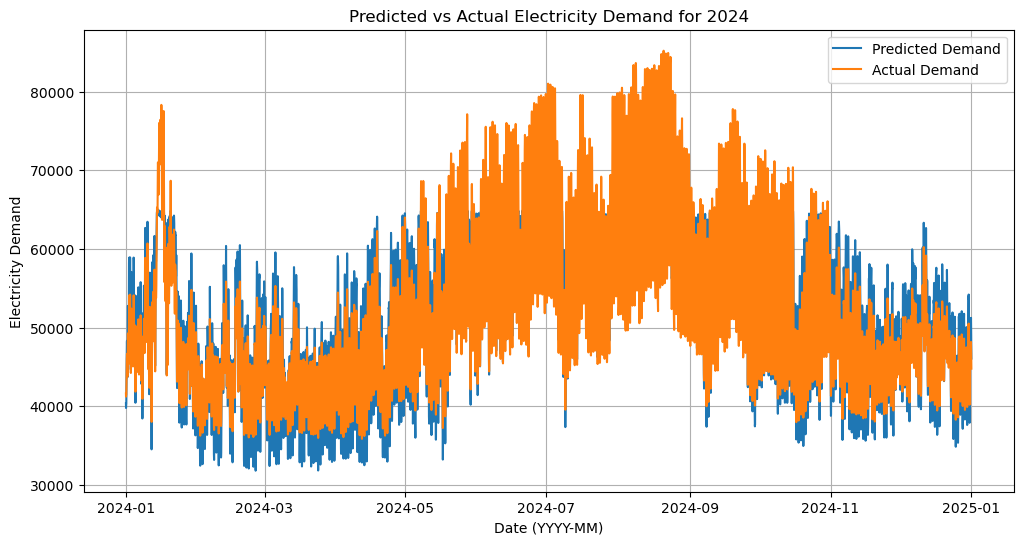

In [544]:
# Plotting
plt.figure(figsize=(12, 6))
plt.plot(merged_df['timestamp'], merged_df['predicted_demand'], label='Predicted Demand')
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual Demand')
plt.xlabel('Date (YYYY-MM)')
plt.ylabel('Electricity Demand')
plt.title('Predicted vs Actual Electricity Demand for 2024')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\sajib\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


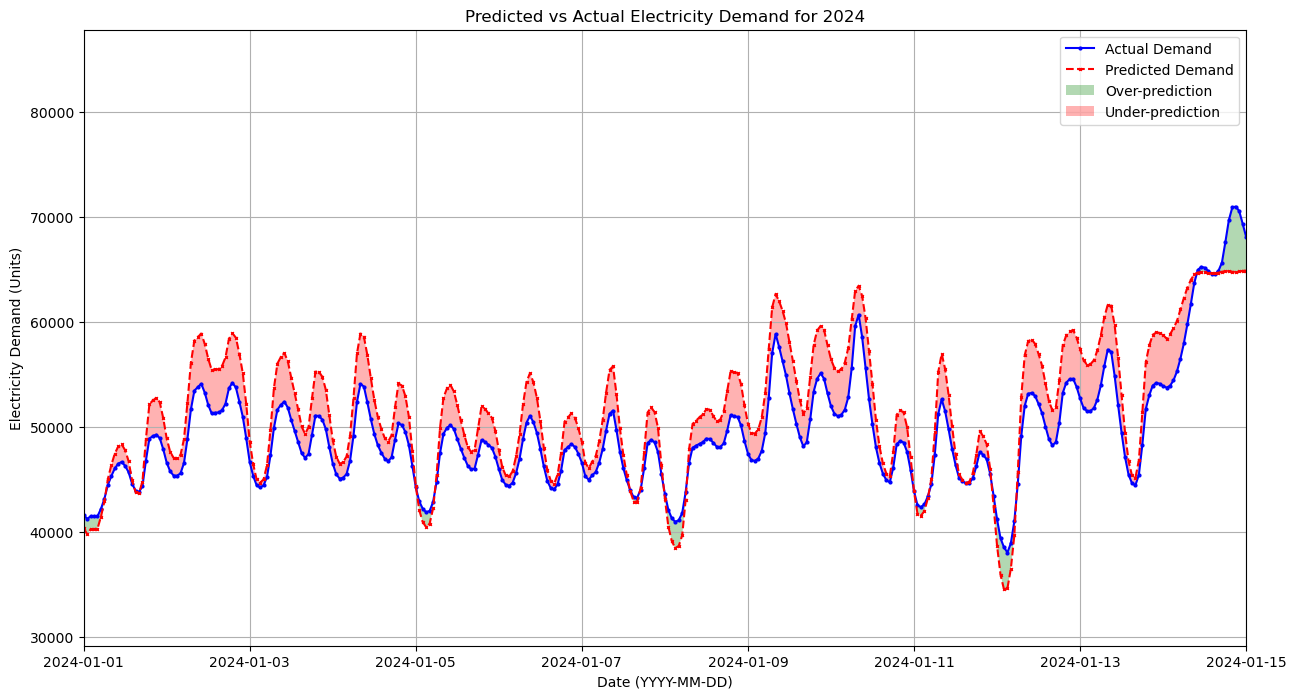

In [545]:

# Plotting
plt.figure(figsize=(15, 8))

# Plot actual demand
plt.plot(merged_df['timestamp'], merged_df['ERCOT'], label='Actual Demand', color='blue', linestyle='-', marker='o', markersize=2)

# Plot predicted demand
plt.plot(merged_df['timestamp'], merged_df['predicted_demand'], label='Predicted Demand', color='red', linestyle='--', marker='x', markersize=2)

# Highlight prediction errors
plt.fill_between(merged_df['timestamp'], merged_df['ERCOT'], merged_df['predicted_demand'], where=(merged_df['ERCOT'] >= merged_df['predicted_demand']), facecolor='green', interpolate=True, alpha=0.3, label='Over-prediction')
plt.fill_between(merged_df['timestamp'], merged_df['ERCOT'], merged_df['predicted_demand'], where=(merged_df['ERCOT'] < merged_df['predicted_demand']), facecolor='red', interpolate=True, alpha=0.3, label='Under-prediction')

plt.xlabel('Date (YYYY-MM-DD)')
plt.ylabel('Electricity Demand (Units)')
plt.title('Predicted vs Actual Electricity Demand for 2024')
plt.legend()
plt.grid(True)
plt.xlim(datetime.datetime(2024, 1, 1), datetime.datetime(2024, 1, 15))
plt.show()

In [546]:
# Calculate metrics
mae = mean_absolute_error(merged_df['ERCOT'], merged_df['predicted_demand'])
rmse = np.sqrt(mean_squared_error(merged_df['ERCOT'], merged_df['predicted_demand']))
mape = mean_absolute_percentage_error(merged_df['ERCOT'], merged_df['predicted_demand'])
accuracy = 100 - mape * 100

In [547]:
# Calculate percentage errors
mae_percentage = (mae / merged_df['ERCOT'].mean()) * 100
rmse_percentage = (rmse / merged_df['ERCOT'].mean()) * 100

In [548]:
print(f"Mean Absolute Error Percentage: {mae_percentage:.2f}%")
print(f"Root Mean Square Error Percentage: {rmse_percentage:.2f}%")
print(f"Root Mean Square Error (Units): {rmse:.2f}")
print(f"Final Accuracy: {accuracy:.2f}%")

Mean Absolute Error Percentage: 6.16%
Root Mean Square Error Percentage: 8.63%
Root Mean Square Error (Units): 4534.86
Final Accuracy: 94.28%
